# Variables Aleatorias

## 0. Preparación del ambiente

Usaremos:

- `numpy` para cálculo numérico.
- `pandas` para tablas.
- `matplotlib` para gráficas.
- `scipy.stats` para distribuciones de probabilidad.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import sympy as sp

np.random.seed(42)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


# 1. Definición de variable aleatoria

Dado $\left(\Omega, \mathcal{F}, P\right)$ un espacio de espacio de probabilidad, una **variable aleatoria** es una función que asigna un número real a cada resultado posible de un experimento aleatorio.

Formalmente:

$$
X:\Omega \rightarrow \mathbb{R}
$$

donde:

- $\Omega$ es el espacio muestral.
- $X$ es la variable aleatoria.
- $\omega$ es un resultado particular del experimento.
- $X(\omega)$ es el valor numérico asignado al resultado $\omega$.


## Ejemplo

Experimento: lanzar dos dados.

$$
\Omega=\{(1,1),(1,2),...,(6,6)\}
$$

Definimos:

$$
X=\text{suma de los dos dados}
$$

Entonces:

$$
X(3,5)=8
$$

In [3]:
# Espacio muestral: dos dados
omega = [(d1, d2) for d1 in range(1, 7) for d2 in range(1, 7)]

# Variable aleatoria X = suma de los dos dados
X = {resultado: sum(resultado) for resultado in omega}

print("Tamaño del espacio muestral:", len(omega))
print("Primeros valores de X:")
list(X.items())[:10]

Tamaño del espacio muestral: 36
Primeros valores de X:


[((1, 1), 2),
 ((1, 2), 3),
 ((1, 3), 4),
 ((1, 4), 5),
 ((1, 5), 6),
 ((1, 6), 7),
 ((2, 1), 3),
 ((2, 2), 4),
 ((2, 3), 5),
 ((2, 4), 6)]

# 2. Función de distribución acumulada, CDF

La **función de distribución acumulada**, también llamada CDF por sus siglas en inglés, se define como:

$$
F_X(x)=P(X\leq x)
$$

La CDF responde esta pregunta:

> ¿Cuál es la probabilidad de que la variable aleatoria tome un valor menor o igual que $x$?

La CDF existe para cualquier variable aleatoria:

- discreta,
- continua,
- mixta.

## Propiedades de la CDF

Toda CDF cumple:

1. $0 \leq F_X(x) \leq 1$
2. Es no decreciente.
3. Es continua por la derecha.
4. $\lim_{x\to-\infty}F_X(x)=0$
5. $\lim_{x\to\infty}F_X(x)=1$

# 2.1 Fórmulas explícitas de la CDF

La CDF siempre se define como:

$$
F_X(x)=P(X\leq x)
$$

pero su forma de cálculo cambia dependiendo de si la variable aleatoria es discreta o continua.

## Caso discreto

Si $X$ es una variable aleatoria discreta con PMF $p_X(x)$, entonces la CDF se calcula sumando las probabilidades hasta $x$:

$$
F_X(x)=P(X\leq x)=\sum_{x_i\leq x}p_X(x_i)
$$

Como:

$$
p_X(x_i)=P(X=x_i)
$$

también podemos escribir:

$$
F_X(x)=\sum_{x_i\leq x}P(X=x_i)
$$

### Ejemplo discreto: suma de dos dados

Si $X$ es la suma de dos dados, entonces:

$$
F_X(5)=P(X\leq5)
$$

Esto equivale a:

$$
F_X(5)=P(X=2)+P(X=3)+P(X=4)+P(X=5)
$$

## Caso continuo

Si $X$ es una variable aleatoria continua con PDF $f_X(x)$, entonces la CDF se calcula integrando la densidad desde $-\infty$ hasta $x$:

$$
F_X(x)=P(X\leq x)=\int_{-\infty}^{x}f_X(t)\,dt
$$

La probabilidad en un intervalo se obtiene restando dos valores de la CDF:

$$
P(a\leq X\leq b)=F_X(b)-F_X(a)
$$

y usando la forma integral:

$$
P(a\leq X\leq b)=\int_a^b f_X(t)\,dt
$$

Si $F_X(x)$ es derivable, la PDF se puede recuperar derivando la CDF:

$$
f_X(x)=F_X'(x)=\frac{d}{dx}F_X(x)
$$

### Ejemplo continuo: normal estándar

Si:

$$
X\sim N(0,1)
$$

entonces:

$$
F_X(x)=P(X\leq x)=\int_{-\infty}^{x}
\frac{1}{\sqrt{2\pi}}e^{-t^2/2}\,dt
$$



# 3. Función de masa de probabilidad, PMF

La **función de masa de probabilidad**, PMF por sus siglas en inglés, se usa para variables aleatorias **discretas**.

Se define como:

$$
p_X(x)=P(X=x)
$$

La PMF responde esta pregunta:

> ¿Cuál es la probabilidad exacta de que $X$ tome el valor $x$?

## Condiciones de una PMF

Debe cumplir:

$$
p_X(x)\geq 0
$$

y

$$
\sum_x p_X(x)=1
$$

## Relación entre PMF y CDF

Para una variable discreta:

$$
F_X(x)=P(X\leq x)=\sum_{t\leq x}p_X(t)
$$

In [8]:
# PMF exacta para X = suma de dos dados
valores, conteos = np.unique(list(X.values()), return_counts=True)

pmf_dados = pd.DataFrame({
    "x": valores,
    "conteo": conteos,
    "P(X=x)": conteos / len(omega)
})

pmf_dados["F(X<=x)"] = pmf_dados["P(X=x)"].cumsum()
pmf_dados

,x,conteo,P(X=x),F(X<=x)
0,2,1,0.027778,0.027778
1,3,2,0.055556,0.083333
2,4,3,0.083333,0.166667
3,5,4,0.111111,0.277778
4,6,5,0.138889,0.416667
5,7,6,0.166667,0.583333
6,8,5,0.138889,0.722222
7,9,4,0.111111,0.833333
8,10,3,0.083333,0.916667
9,11,2,0.055556,0.972222


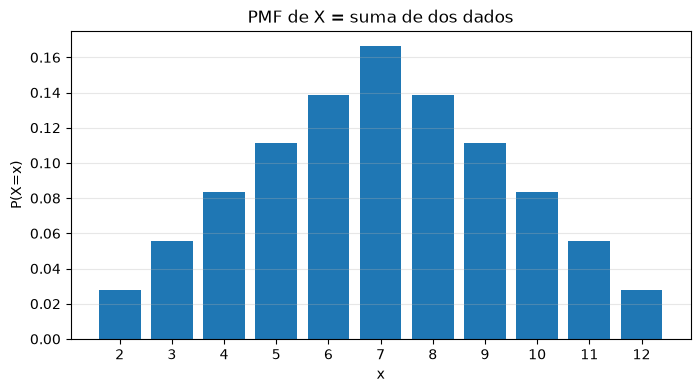

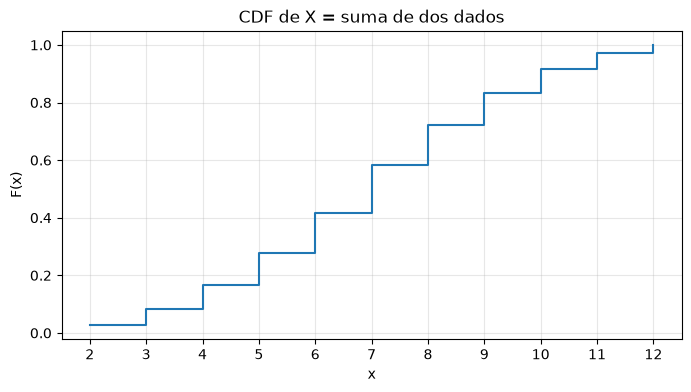

In [9]:
plt.figure(figsize=(8, 4))
plt.bar(pmf_dados["x"], pmf_dados["P(X=x)"])
plt.title("PMF de X = suma de dos dados")
plt.xlabel("x")
plt.ylabel("P(X=x)")
plt.xticks(pmf_dados["x"])
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.step(pmf_dados["x"], pmf_dados["F(X<=x)"], where="post")
plt.title("CDF de X = suma de dos dados")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.xticks(pmf_dados["x"])
plt.grid(alpha=0.3)
plt.show()

# 4. Función de densidad de probabilidad, PDF

La **función de densidad de probabilidad**, PDF por sus siglas en inglés, se usa para variables aleatorias **continuas**.

Se denota como:

$$
f_X(x)
$$

A diferencia de una PMF, una PDF **no da probabilidades puntuales**.

En una variable continua:

$$
P(X=x)=0
$$

Las probabilidades se calculan sobre intervalos:

$$
P(a\leq X\leq b)=\int_a^b f_X(x)\,dx
$$

## Condiciones de una PDF

Debe cumplir:

$$
f_X(x)\geq 0
$$

y

$$
\int_{-\infty}^{\infty} f_X(x)\,dx=1
$$

## Relación entre PDF y CDF

Para una variable continua:

$$
F_X(x)=\int_{-\infty}^{x}f_X(t)\,dt
$$

Si la CDF es derivable:

$$
f_X(x)=\frac{d}{dx}F_X(x)
$$

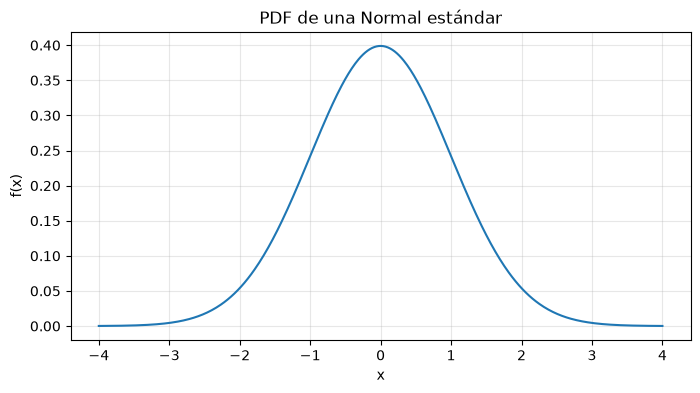

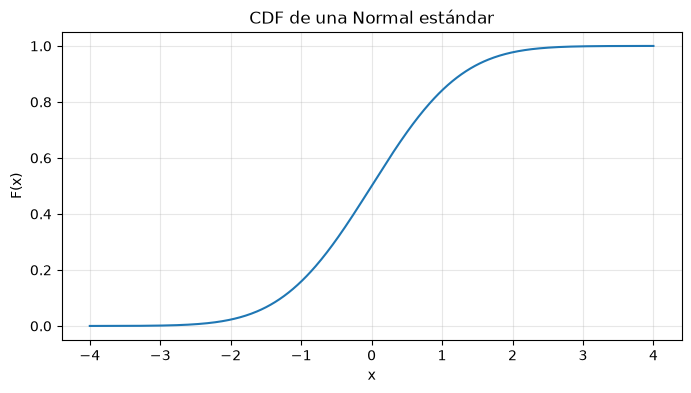

In [10]:
# Ejemplo de PDF y CDF con una Normal estándar
x = np.linspace(-4, 4, 500)

normal_estandar = stats.norm(loc=0, scale=1)
pdf = normal_estandar.pdf(x)
cdf = normal_estandar.cdf(x)

plt.figure(figsize=(8, 4))
plt.plot(x, pdf)
plt.title("PDF de una Normal estándar")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(x, cdf)
plt.title("CDF de una Normal estándar")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.grid(alpha=0.3)
plt.show()

# 5. Tipos de variables aleatorias

Después de definir variable aleatoria, CDF, PMF y PDF, podemos clasificar las variables aleatorias.

## 5.1 Variable aleatoria discreta

Toma valores en un conjunto finito o numerable.

Ejemplos:

- Resultado de lanzar un dado.
- Número de clientes que llegan en una hora.
- Número de defectos en un lote.
- Número de éxitos en varios intentos.

Las variables discretas se describen principalmente con una **PMF**.

## 5.2 Variable aleatoria continua

Toma valores en un intervalo de números reales.

Ejemplos:

- Tiempo de espera.
- Estatura.
- Peso.
- Temperatura.
- Tiempo de vida de un componente.

Las variables continuas se describen principalmente con una **PDF**.

## 5.3 Variable aleatoria mixta

Tiene una parte discreta y una parte continua.

Ejemplo: un tiempo de espera donde existe probabilidad positiva de que el tiempo sea exactamente cero, pero si no es cero puede tomar valores continuos.

# 6. Esperanza, varianza y desviación estándar

## 6.1 Esperanza

La esperanza es el promedio teórico de una variable aleatoria.

Para una variable discreta:

$$
E[X]=\sum_x x p_X(x)
$$

Para una variable continua:

$$
E[X]=\int_{-\infty}^{\infty}x f_X(x)\,dx
$$

## 6.2 Varianza

La varianza mide la dispersión alrededor de la esperanza.

$$
Var(X)=E[(X-E[X])^2]
$$

También se puede calcular como:

$$
Var(X)=E[X^2]-[E[X]]^2
$$

## 6.3 Desviación estándar

$$
\sigma_X=\sqrt{Var(X)}
$$

In [11]:
# Esperanza y varianza de X = suma de dos dados
EX = np.sum(pmf_dados["x"] * pmf_dados["P(X=x)"])
EX2 = np.sum((pmf_dados["x"] ** 2) * pmf_dados["P(X=x)"])
VarX = EX2 - EX**2
StdX = np.sqrt(VarX)

print("E[X] =", EX)
print("Var(X) =", VarX)
print("Desviación estándar =", StdX)

E[X] = 6.999999999999998
Var(X) = 5.833333333333364
Desviación estándar = 2.415229457698246


# 7. Uso básico de `scipy.stats`

En `scipy.stats`, las distribuciones suelen tener métodos como:

| Método | Significado |
|---|---|
| `.pmf(x)` | Probabilidad puntual para distribuciones discretas |
| `.pdf(x)` | Densidad para distribuciones continuas |
| `.cdf(x)` | Función de distribución acumulada |
| `.sf(x)` | Supervivencia, es decir, `P(X > x)` |
| `.ppf(q)` | Cuantil inverso |
| `.mean()` | Esperanza |
| `.var()` | Varianza |
| `.std()` | Desviación estándar |
| `.rvs(size=n)` | Simulación aleatoria |
| `.stats(moments="mv")` | Media y varianza |

In [ ]:
# Ejemplo rápido con una Binomial: X ~ Binomial(n=10, p=0.3)
dist = stats.binom(n=10, p=0.3)

print("P(X=3):", dist.pmf(3))
print("P(X<=3):", dist.cdf(3))
print("P(X>3):", dist.sf(3))
print("E[X]:", dist.mean())
print("Var(X):", dist.var())
print("Simulación:", dist.rvs(size=10, random_state=42))

# Parte I: Variables aleatorias discretas

Una variable aleatoria discreta toma valores en un conjunto finito o numerable.

Se trabaja principalmente con:

$$
p_X(x)=P(X=x)
$$

es decir, con la **PMF**.

## 8. Distribuciones discretas principales

| Distribución | Notación | Soporte | PMF | Esperanza | Varianza | Python |
|---|---|---|---|---|---|---|
| Uniforme discreta | $U\{a,\dots,b\}$ | $a,\dots,b$ | $\frac{1}{b-a+1}$ | $\frac{a+b}{2}$ | $\frac{(b-a+1)^2-1}{12}$ | `stats.randint(a,b+1)` |
| Bernoulli | $Bernoulli(p)$ | $0,1$ | $p^x(1-p)^{1-x}$ | $p$ | $p(1-p)$ | `stats.bernoulli(p)` |
| Binomial | $Bin(n,p)$ | $0,\dots,n$ | $\binom{n}{x}p^x(1-p)^{n-x}$ | $np$ | $np(1-p)$ | `stats.binom(n,p)` |
| Geométrica | $Geom(p)$ | $1,2,\dots$ | $(1-p)^{x-1}p$ | $\frac{1}{p}$ | $\frac{1-p}{p^2}$ | `stats.geom(p)` |
| Binomial negativa | $NB(r,p)$ | $0,1,\dots$ | $\binom{x+r-1}{x}p^r(1-p)^x$ | $\frac{r(1-p)}{p}$ | $\frac{r(1-p)}{p^2}$ | `stats.nbinom(r,p)` |
| Hipergeométrica | $H(N,K,n)$ | depende de $N,K,n$ | $\frac{\binom{K}{x}\binom{N-K}{n-x}}{\binom{N}{n}}$ | $n\frac{K}{N}$ | $n\frac{K}{N}(1-\frac{K}{N})\frac{N-n}{N-1}$ | `stats.hypergeom(M=N,n=K,N=n)` |
| Poisson | $Pois(\lambda)$ | $0,1,\dots$ | $\frac{e^{-\lambda}\lambda^x}{x!}$ | $\lambda$ | $\lambda$ | `stats.poisson(mu=lambda)` |
| Multinomial | $Mult(n,p_1,\dots,p_k)$ | conteos por categoría | $\frac{n!}{x_1!\cdots x_k!}\prod p_i^{x_i}$ | $np_i$ | $np_i(1-p_i)$ | `stats.multinomial(n,p)` |

> Nota sobre `scipy.stats.nbinom`: en SciPy, la binomial negativa representa el número de **fracasos** antes de obtener `r` éxitos.

In [12]:
def resumen_dist(nombre, dist):
    return {
        "Distribución": nombre,
        "Esperanza": dist.mean(),
        "Varianza": dist.var(),
        "Desv. estándar": dist.std()
    }

discretas = [
    {
        "nombre": "Uniforme discreta U{1,...,6}",
        "dist": stats.randint(low=1, high=7),
        "x": np.arange(1, 7)
    },
    {
        "nombre": "Bernoulli(p=0.7)",
        "dist": stats.bernoulli(p=0.7),
        "x": np.array([0, 1])
    },
    {
        "nombre": "Binomial(n=20, p=0.35)",
        "dist": stats.binom(n=20, p=0.35),
        "x": np.arange(0, 21)
    },
    {
        "nombre": "Geométrica(p=0.25)",
        "dist": stats.geom(p=0.25),
        "x": np.arange(1, 21)
    },
    {
        "nombre": "Binomial negativa(r=5, p=0.4)",
        "dist": stats.nbinom(n=5, p=0.4),
        "x": np.arange(0, 31)
    },
    {
        "nombre": "Hipergeométrica(N=50, K=15, n=10)",
        "dist": stats.hypergeom(M=50, n=15, N=10),
        "x": np.arange(max(0, 10-(50-15)), min(10, 15)+1)
    },
    {
        "nombre": "Poisson(lambda=4)",
        "dist": stats.poisson(mu=4),
        "x": np.arange(0, 16)
    }
]

pd.DataFrame([resumen_dist(d["nombre"], d["dist"]) for d in discretas])

,Distribución,Esperanza,Varianza,Desv. estándar
0,"Uniforme discreta U{1,...,6}",3.5,2.916667,1.707825
1,Bernoulli(p=0.7),0.7,0.210000,0.458258
2,"Binomial(n=20, p=0.35)",7.0,4.550000,2.133073
3,Geométrica(p=0.25),4.0,12.000000,3.464102
4,"Binomial negativa(r=5, p=0.4)",7.5,18.750000,4.330127
5,"Hipergeométrica(N=50, K=15, n=10)",3.0,1.714286,1.309307
6,Poisson(lambda=4),4.0,4.000000,2.000000



Uniforme discreta U{1,...,6}
E[X] = 3.5
Var(X) = 2.9166666666666665


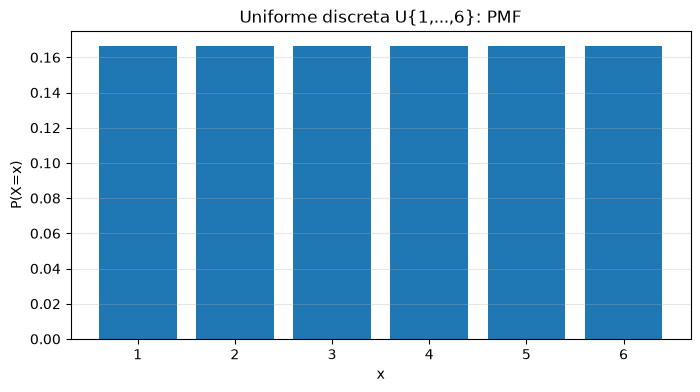

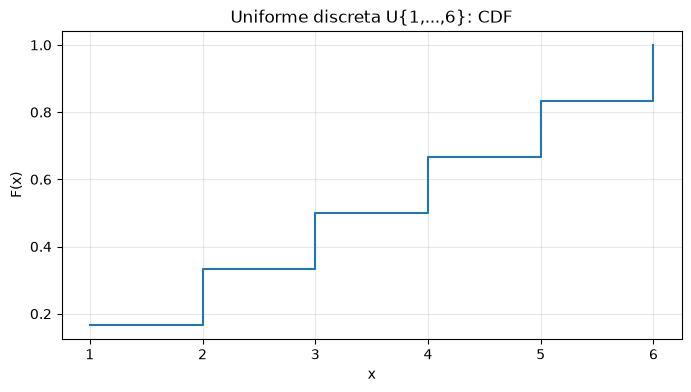


Bernoulli(p=0.7)
E[X] = 0.7
Var(X) = 0.21000000000000002


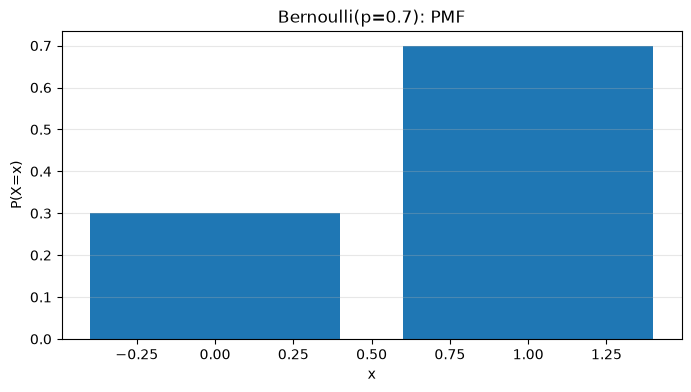

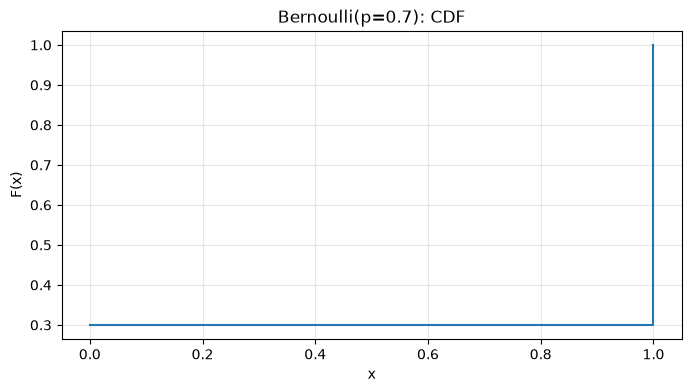


Binomial(n=20, p=0.35)
E[X] = 7.0
Var(X) = 4.550000000000001


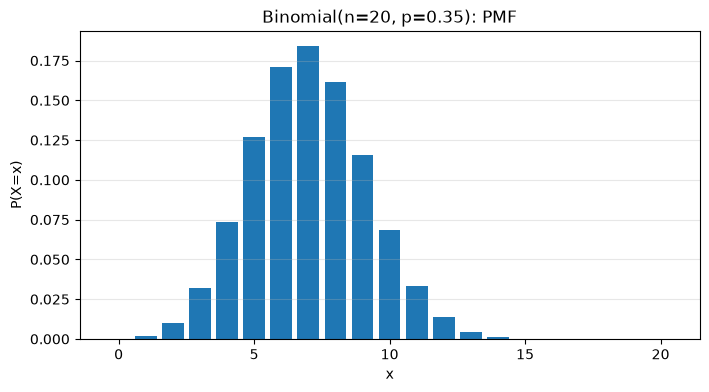

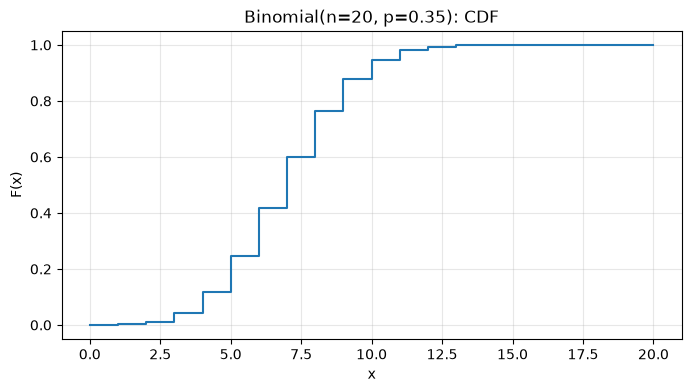


Geométrica(p=0.25)
E[X] = 4.0
Var(X) = 12.0


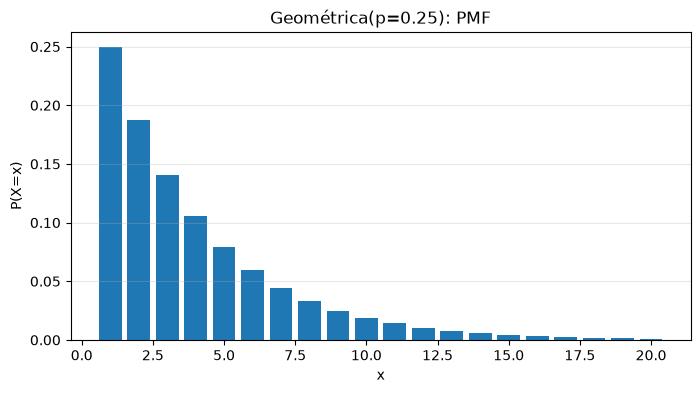

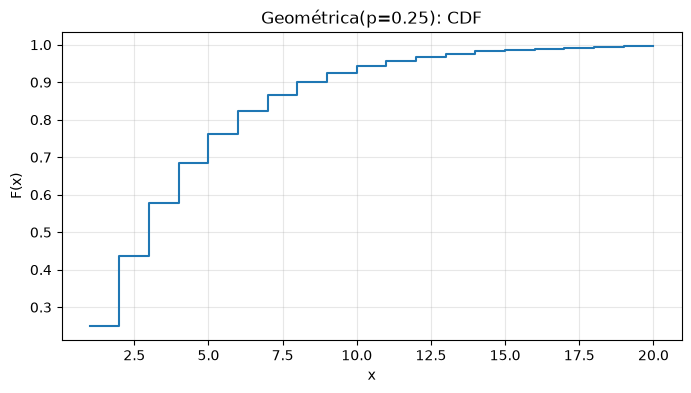


Binomial negativa(r=5, p=0.4)
E[X] = 7.5
Var(X) = 18.749999999999996


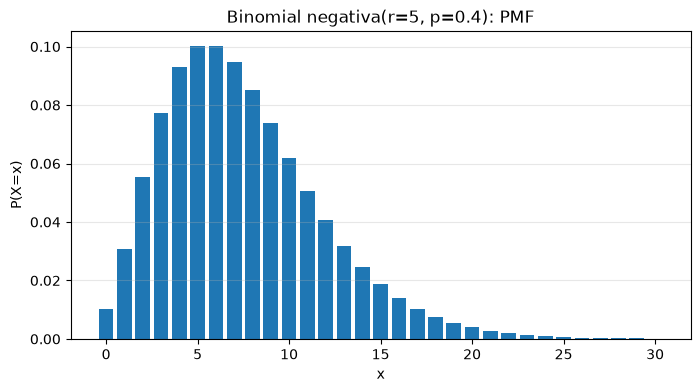

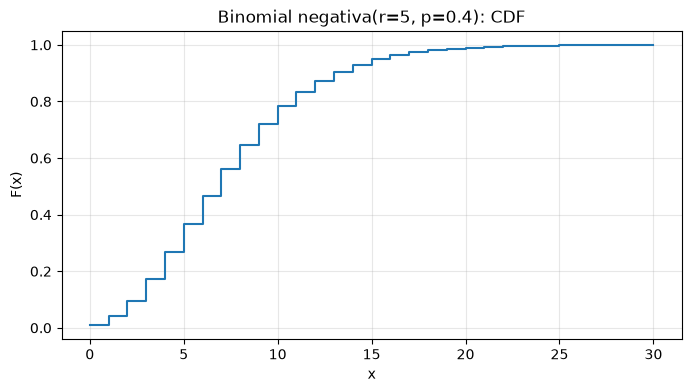


Hipergeométrica(N=50, K=15, n=10)
E[X] = 3.0
Var(X) = 1.7142857142857142


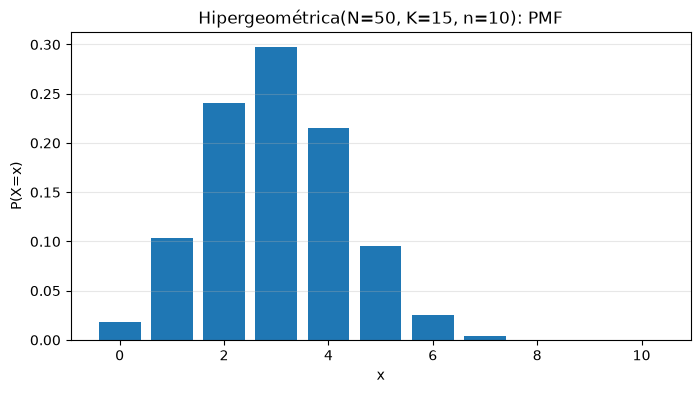

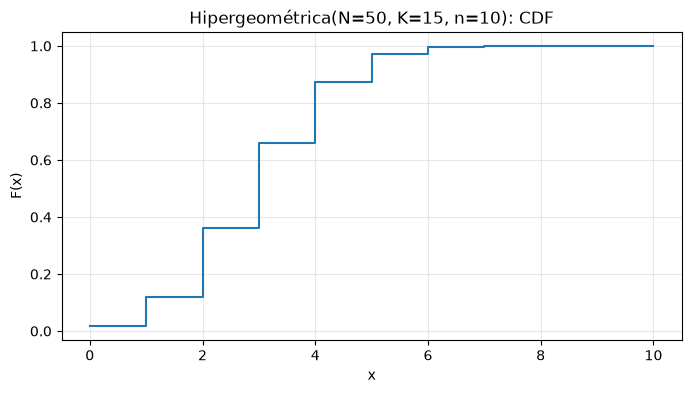


Poisson(lambda=4)
E[X] = 4.0
Var(X) = 4.0


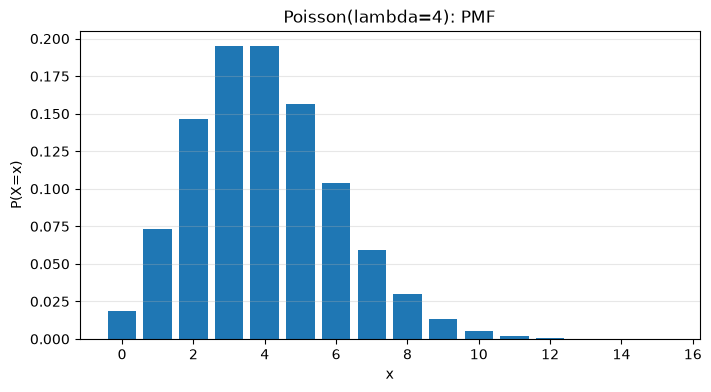

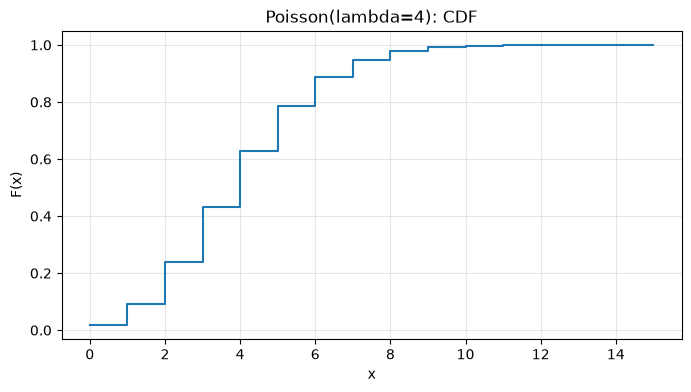

In [13]:
def graficar_discreta(nombre, dist, x):
    pmf = dist.pmf(x)
    cdf = dist.cdf(x)

    plt.figure(figsize=(8, 4))
    plt.bar(x, pmf)
    plt.title(f"{nombre}: PMF")
    plt.xlabel("x")
    plt.ylabel("P(X=x)")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.step(x, cdf, where="post")
    plt.title(f"{nombre}: CDF")
    plt.xlabel("x")
    plt.ylabel("F(x)")
    plt.grid(alpha=0.3)
    plt.show()

# Ejecuta esta celda para graficar todas las distribuciones discretas.
for d in discretas:
    print("\n" + d["nombre"])
    print("E[X] =", d["dist"].mean())
    print("Var(X) =", d["dist"].var())
    graficar_discreta(d["nombre"], d["dist"], d["x"])

# Parte II: Variables aleatorias continuas

Una variable aleatoria continua toma valores en un intervalo de números reales.

Se trabaja principalmente con:

$$
f_X(x)
$$

es decir, con la **PDF**.

Las probabilidades se calculan sobre intervalos:

$$
P(a\leq X\leq b)=\int_a^b f_X(x)\,dx
$$

## 9. Distribuciones continuas principales

| Distribución | Notación | Soporte | PDF / idea | Esperanza | Varianza | Python |
|---|---|---|---|---|---|---|
| Uniforme continua | $U(a,b)$ | $[a,b]$ | $\frac{1}{b-a}$ | $\frac{a+b}{2}$ | $\frac{(b-a)^2}{12}$ | `stats.uniform(loc=a, scale=b-a)` |
| Exponencial | $Exp(\lambda)$ | $x\geq0$ | $\lambda e^{-\lambda x}$ | $\frac{1}{\lambda}$ | $\frac{1}{\lambda^2}$ | `stats.expon(scale=1/lambda)` |
| Gamma | $Gamma(\alpha,\theta)$ | $x>0$ | $\frac{x^{\alpha-1}e^{-x/\theta}}{\Gamma(\alpha)\theta^\alpha}$ | $\alpha\theta$ | $\alpha\theta^2$ | `stats.gamma(a=alpha, scale=theta)` |
| Erlang | $Erlang(k,\lambda)$ | $x>0$ | Gamma con $k$ entero | $\frac{k}{\lambda}$ | $\frac{k}{\lambda^2}$ | `stats.gamma(a=k, scale=1/lambda)` |
| Normal | $N(\mu,\sigma^2)$ | $\mathbb{R}$ | campana normal | $\mu$ | $\sigma^2$ | `stats.norm(loc=mu, scale=sigma)` |
| Lognormal | $LogN(\mu,\sigma^2)$ | $x>0$ | $\ln(X)\sim N(\mu,\sigma^2)$ | $e^{\mu+\sigma^2/2}$ | $(e^{\sigma^2}-1)e^{2\mu+\sigma^2}$ | `stats.lognorm(s=sigma, scale=exp(mu))` |
| Beta | $Beta(\alpha,\beta)$ | $(0,1)$ | proporcional a $x^{\alpha-1}(1-x)^{\beta-1}$ | $\frac{\alpha}{\alpha+\beta}$ | $\frac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)}$ | `stats.beta(a,b)` |
| Chi-cuadrada | $\chi^2_k$ | $x>0$ | suma de normales estándar al cuadrado | $k$ | $2k$ | `stats.chi2(df=k)` |
| t de Student | $t_\nu$ | $\mathbb{R}$ | colas más pesadas que normal | $0$, si $\nu>1$ | $\frac{\nu}{\nu-2}$, si $\nu>2$ | `stats.t(df=nu)` |
| F | $F(d_1,d_2)$ | $x>0$ | razón de chi-cuadradas escaladas | $\frac{d_2}{d_2-2}$ | fórmula con $d_1,d_2$ | `stats.f(dfn=d1, dfd=d2)` |
| Weibull | $Weibull(k,\lambda)$ | $x\geq0$ | confiabilidad y tiempos de vida | $\lambda\Gamma(1+1/k)$ | fórmula con $\Gamma$ | `stats.weibull_min(c=k, scale=lambda)` |
| Pareto | $Pareto(\alpha,x_m)$ | $x\geq x_m$ | colas pesadas | $\frac{\alpha x_m}{\alpha-1}$, si $\alpha>1$ | $\frac{\alpha x_m^2}{(\alpha-1)^2(\alpha-2)}$, si $\alpha>2$ | `stats.pareto(b=alpha, scale=xm)` |
| Cauchy | $Cauchy(x_0,\gamma)$ | $\mathbb{R}$ | colas muy pesadas | no existe | no existe | `stats.cauchy(loc=x0, scale=gamma)` |
| Laplace | $Laplace(\mu,b)$ | $\mathbb{R}$ | doble exponencial | $\mu$ | $2b^2$ | `stats.laplace(loc=mu, scale=b)` |
| Logística | $Logistic(\mu,s)$ | $\mathbb{R}$ | parecida a la normal | $\mu$ | $\frac{\pi^2s^2}{3}$ | `stats.logistic(loc=mu, scale=s)` |
| Triangular | $Triangular(a,c,b)$ | $[a,b]$ | mínimo, máximo y moda | $\frac{a+b+c}{3}$ | $\frac{a^2+b^2+c^2-ab-ac-bc}{18}$ | `stats.triang(c, loc=a, scale=b-a)` |

In [14]:
continuas = [
    {
        "nombre": "Uniforme continua U(2,8)",
        "dist": stats.uniform(loc=2, scale=6),
        "x": np.linspace(1, 9, 500)
    },
    {
        "nombre": "Exponencial(lambda=0.5)",
        "dist": stats.expon(scale=1/0.5),
        "x": np.linspace(0, 12, 500)
    },
    {
        "nombre": "Gamma(alpha=3, theta=2)",
        "dist": stats.gamma(a=3, scale=2),
        "x": np.linspace(0, 25, 500)
    },
    {
        "nombre": "Erlang(k=4, lambda=1.5)",
        "dist": stats.gamma(a=4, scale=1/1.5),
        "x": np.linspace(0, 8, 500)
    },
    {
        "nombre": "Normal(mu=10, sigma=2)",
        "dist": stats.norm(loc=10, scale=2),
        "x": np.linspace(2, 18, 500)
    },
    {
        "nombre": "Lognormal(mu=0, sigma=0.5)",
        "dist": stats.lognorm(s=0.5, scale=np.exp(0)),
        "x": np.linspace(0.001, 5, 500)
    },
    {
        "nombre": "Beta(alpha=2, beta=5)",
        "dist": stats.beta(a=2, b=5),
        "x": np.linspace(0, 1, 500)
    },
    {
        "nombre": "Chi-cuadrada(k=6)",
        "dist": stats.chi2(df=6),
        "x": np.linspace(0, 25, 500)
    },
    {
        "nombre": "t de Student(nu=5)",
        "dist": stats.t(df=5),
        "x": np.linspace(-5, 5, 500)
    },
    {
        "nombre": "F(d1=5, d2=20)",
        "dist": stats.f(dfn=5, dfd=20),
        "x": np.linspace(0.001, 5, 500)
    },
    {
        "nombre": "Weibull(k=1.5, lambda=2)",
        "dist": stats.weibull_min(c=1.5, scale=2),
        "x": np.linspace(0, 8, 500)
    },
    {
        "nombre": "Pareto(alpha=3, xm=1)",
        "dist": stats.pareto(b=3, scale=1),
        "x": np.linspace(1, 8, 500)
    },
    {
        "nombre": "Cauchy(x0=0, gamma=1)",
        "dist": stats.cauchy(loc=0, scale=1),
        "x": np.linspace(-10, 10, 500)
    },
    {
        "nombre": "Laplace(mu=0, b=1)",
        "dist": stats.laplace(loc=0, scale=1),
        "x": np.linspace(-8, 8, 500)
    },
    {
        "nombre": "Logística(mu=0, s=1)",
        "dist": stats.logistic(loc=0, scale=1),
        "x": np.linspace(-8, 8, 500)
    },
    {
        "nombre": "Triangular(a=0, moda=3, b=10)",
        "dist": stats.triang(c=(3-0)/(10-0), loc=0, scale=10),
        "x": np.linspace(0, 10, 500)
    }
]

pd.DataFrame([resumen_dist(d["nombre"], d["dist"]) for d in continuas])

,Distribución,Esperanza,Varianza,Desv. estándar
0,"Uniforme continua U(2,8)",5.000000,3.000000,1.732051
1,Exponencial(lambda=0.5),2.000000,4.000000,2.000000
2,"Gamma(alpha=3, theta=2)",6.000000,12.000000,3.464102
3,"Erlang(k=4, lambda=1.5)",2.666667,1.777778,1.333333
4,"Normal(mu=10, sigma=2)",10.000000,4.000000,2.000000
5,"Lognormal(mu=0, sigma=0.5)",1.133148,0.364696,0.603901
6,"Beta(alpha=2, beta=5)",0.285714,0.025510,0.159719
7,Chi-cuadrada(k=6),6.000000,12.000000,3.464102
8,t de Student(nu=5),0.000000,1.666667,1.290994
9,"F(d1=5, d2=20)",1.111111,0.709877,0.842542



Uniforme continua U(2,8)
E[X] = 5.0
Var(X) = 3.0


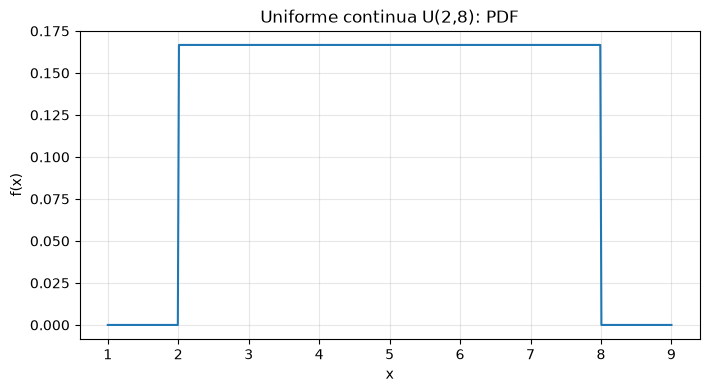

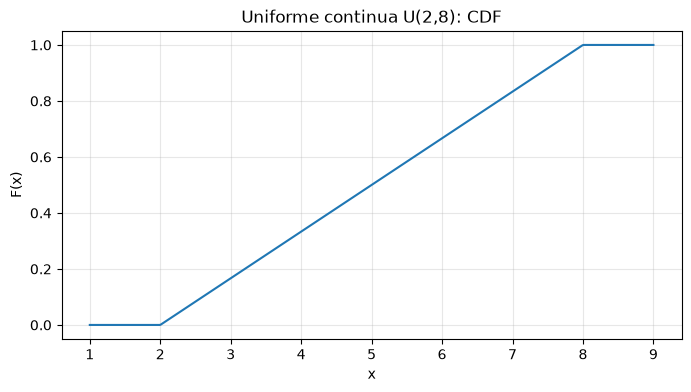


Exponencial(lambda=0.5)
E[X] = 2.0
Var(X) = 4.0


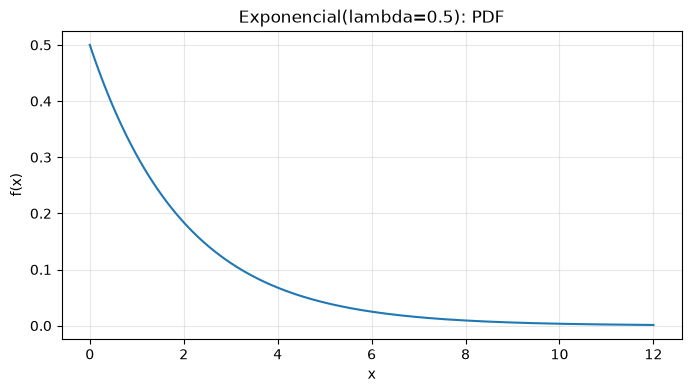

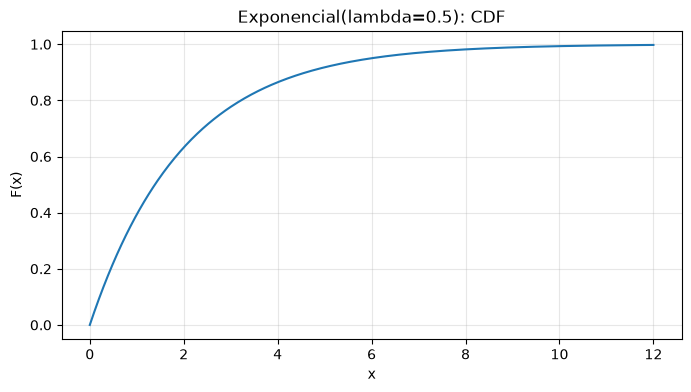


Gamma(alpha=3, theta=2)
E[X] = 6.0
Var(X) = 12.0


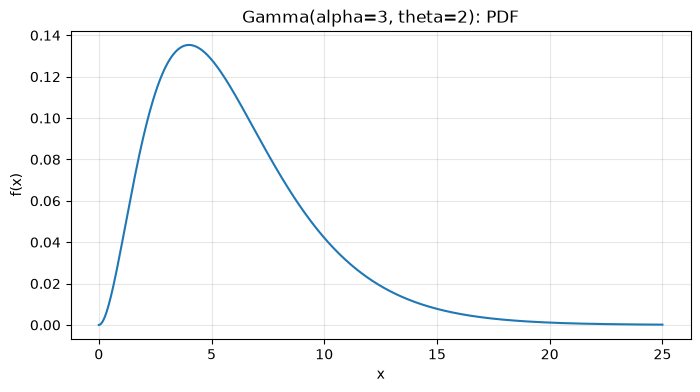

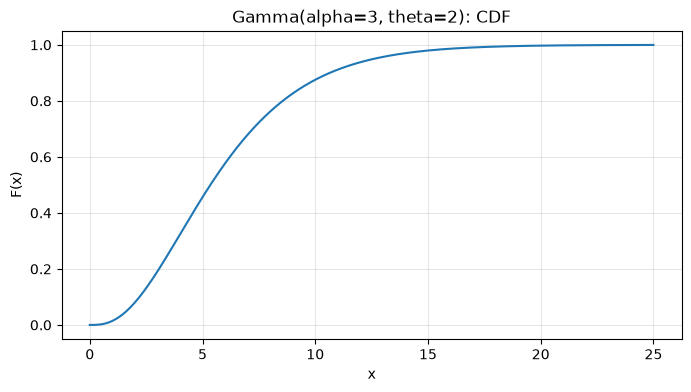


Erlang(k=4, lambda=1.5)
E[X] = 2.6666666666666665
Var(X) = 1.7777777777777777


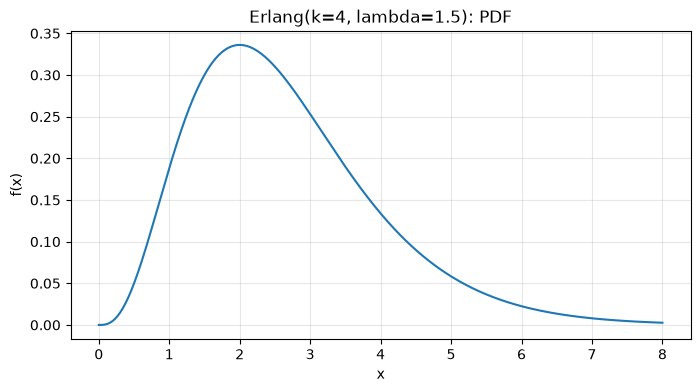

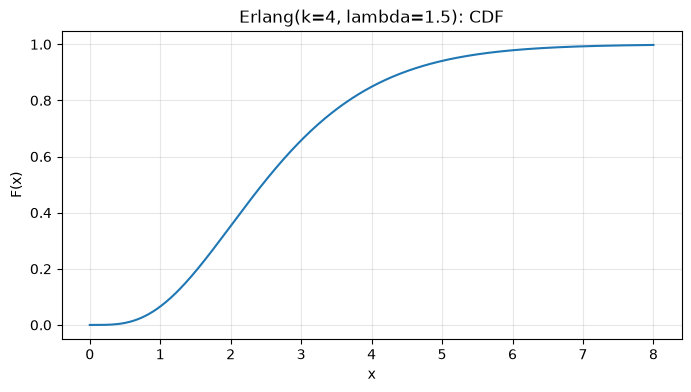


Normal(mu=10, sigma=2)
E[X] = 10.0
Var(X) = 4.0


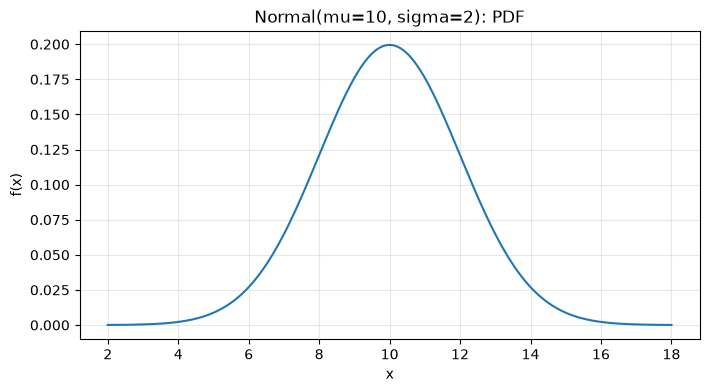

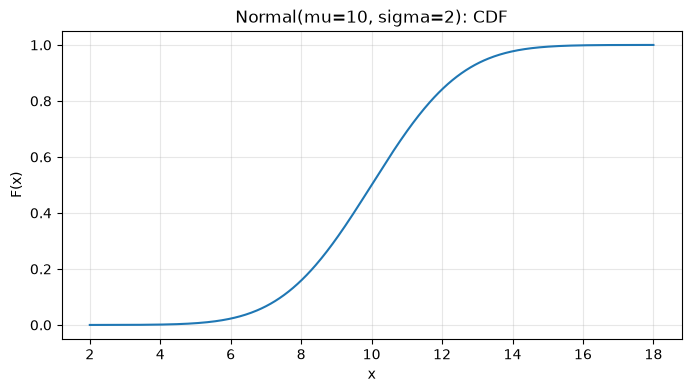


Lognormal(mu=0, sigma=0.5)
E[X] = 1.1331484530668263
Var(X) = 0.3646958540123865


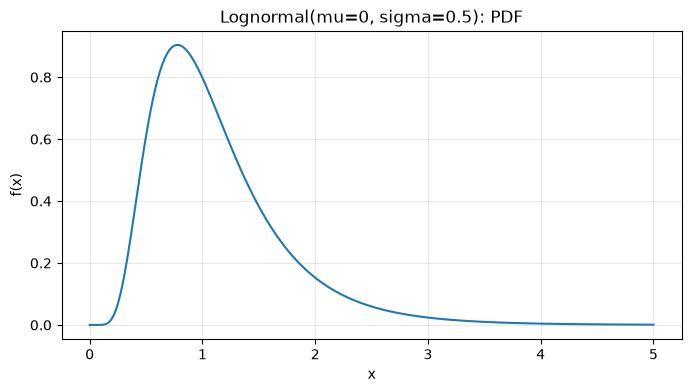

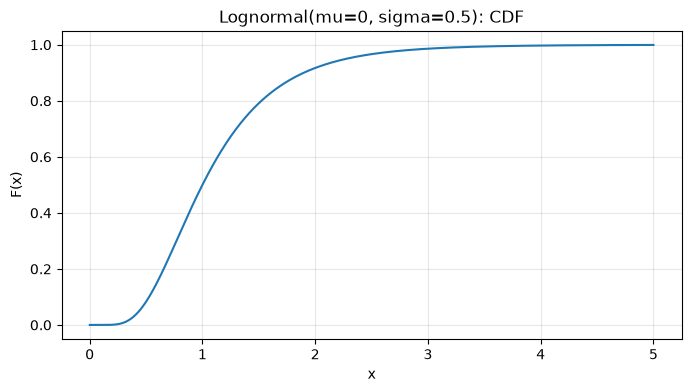


Beta(alpha=2, beta=5)
E[X] = 0.2857142857142857
Var(X) = 0.025510204081632654


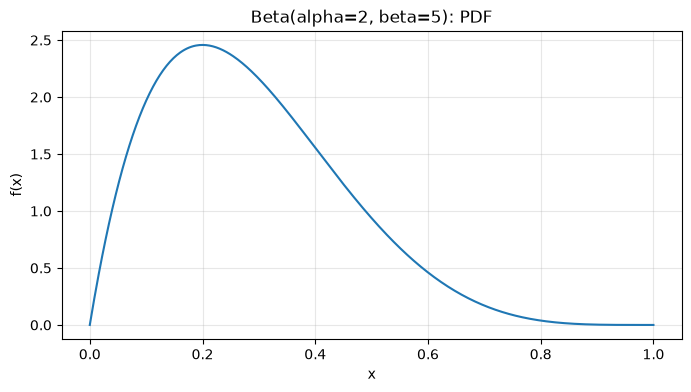

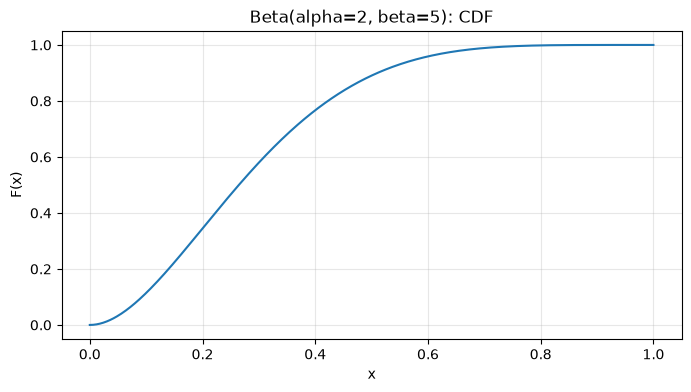


Chi-cuadrada(k=6)
E[X] = 6.0
Var(X) = 12.0


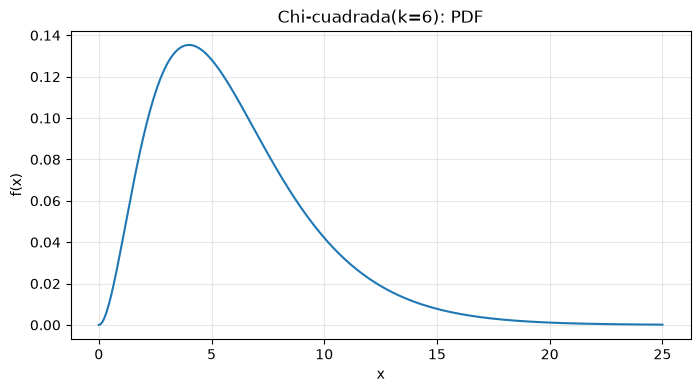

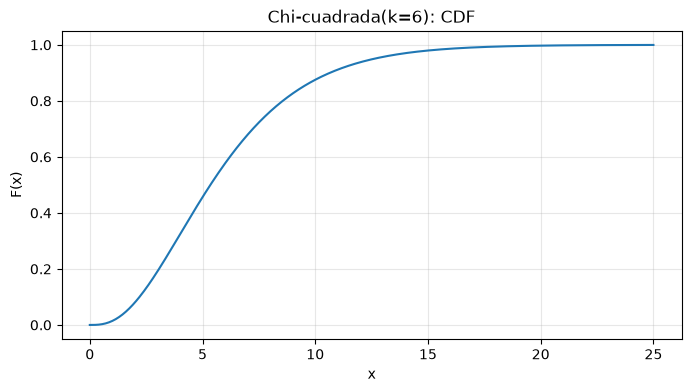


t de Student(nu=5)
E[X] = 0.0
Var(X) = 1.6666666666666667


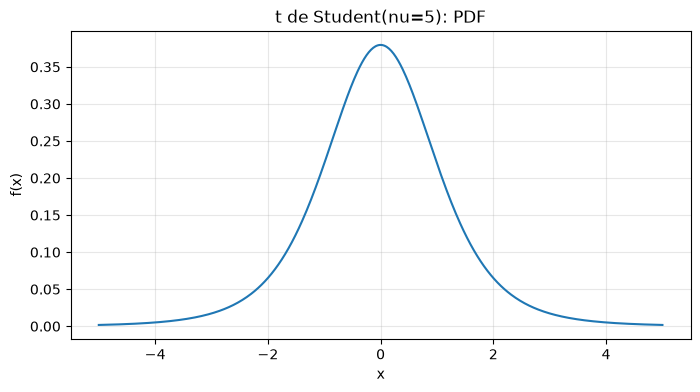

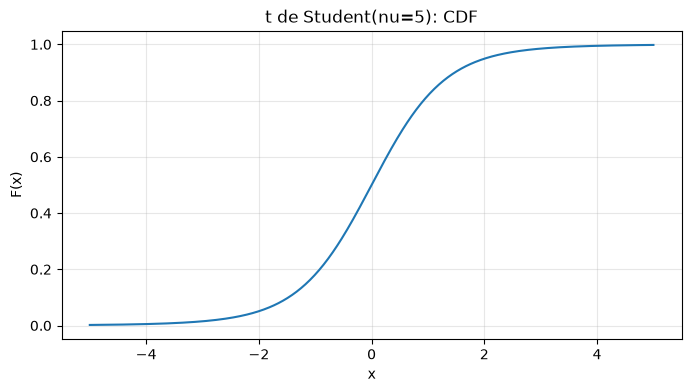


F(d1=5, d2=20)
E[X] = 1.1111111111111112
Var(X) = 0.7098765432098766


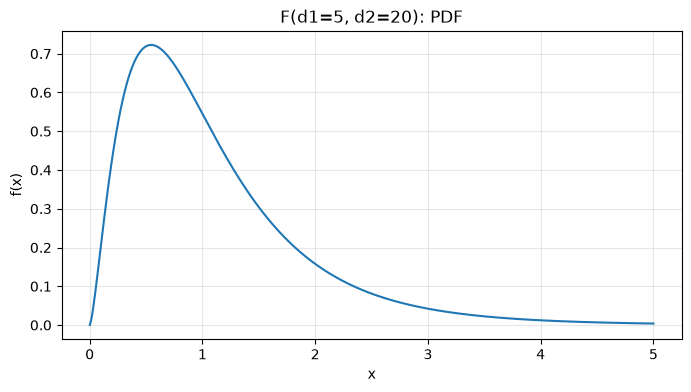

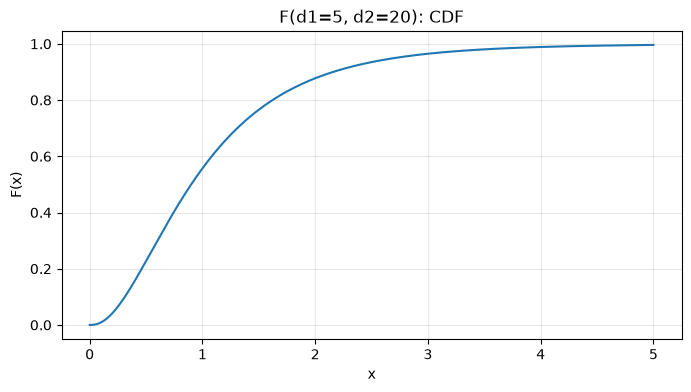


Weibull(k=1.5, lambda=2)
E[X] = 1.805490585901867
Var(X) = 1.5027611392557279


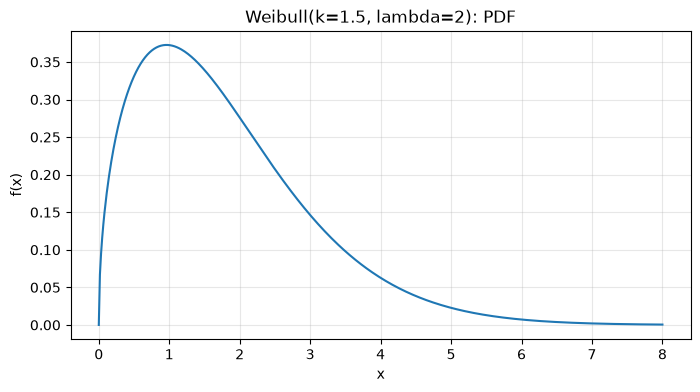

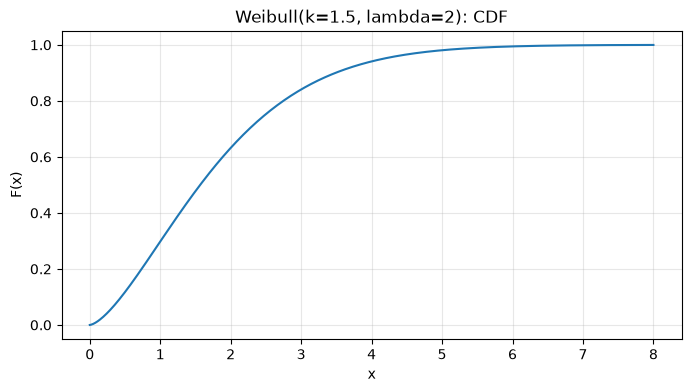


Pareto(alpha=3, xm=1)
E[X] = 1.5
Var(X) = 0.75


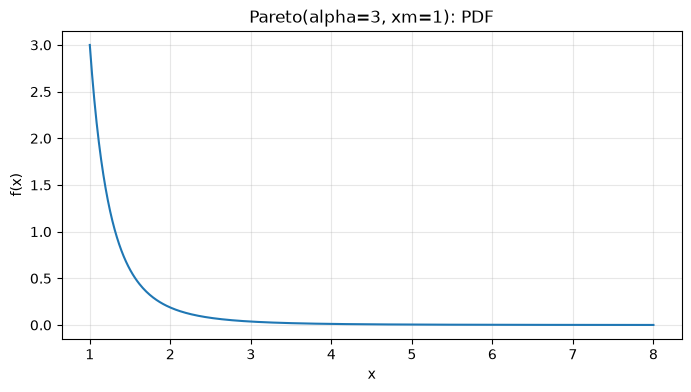

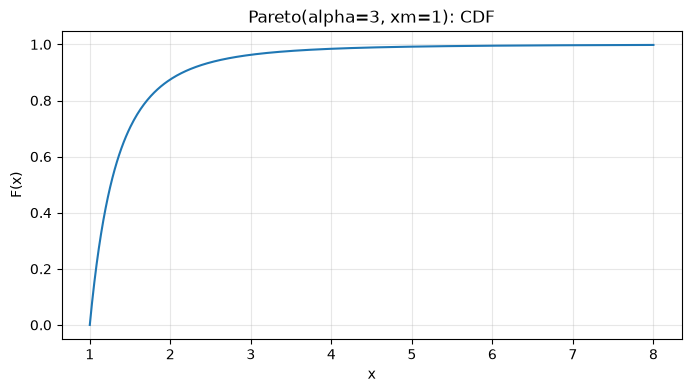


Cauchy(x0=0, gamma=1)
E[X] = nan
Var(X) = nan


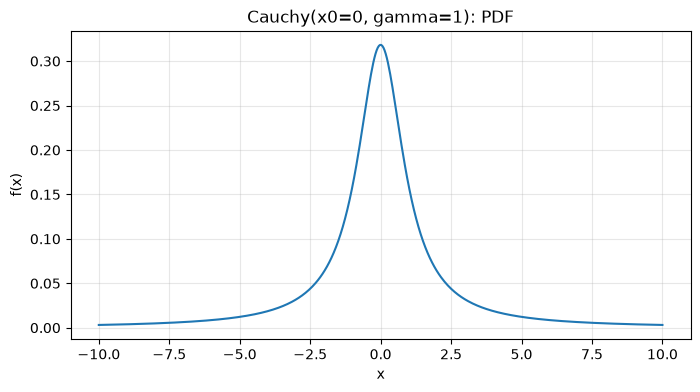

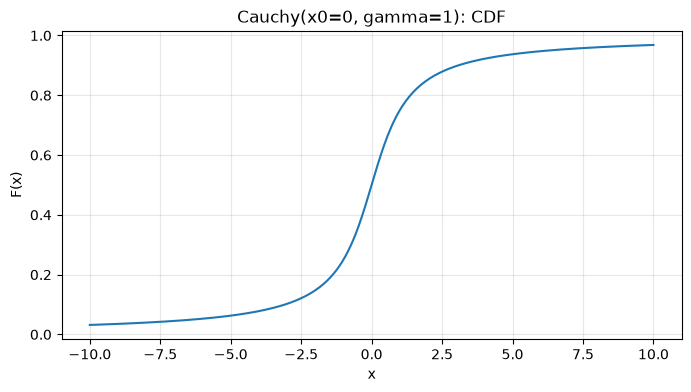


Laplace(mu=0, b=1)
E[X] = 0.0
Var(X) = 2.0


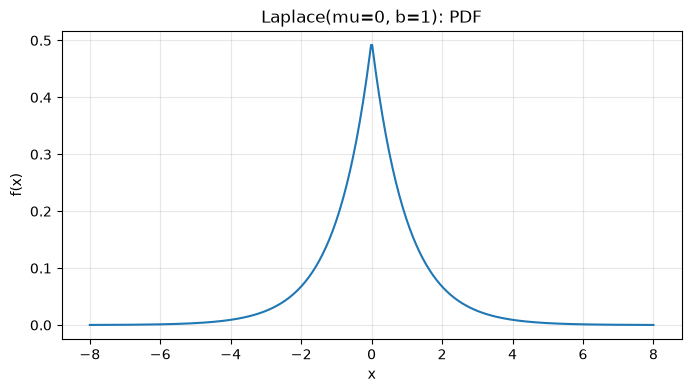

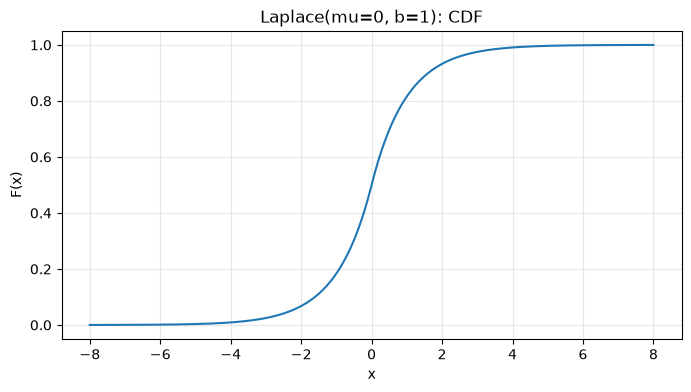


Logística(mu=0, s=1)
E[X] = 0.0
Var(X) = 3.289868133696453


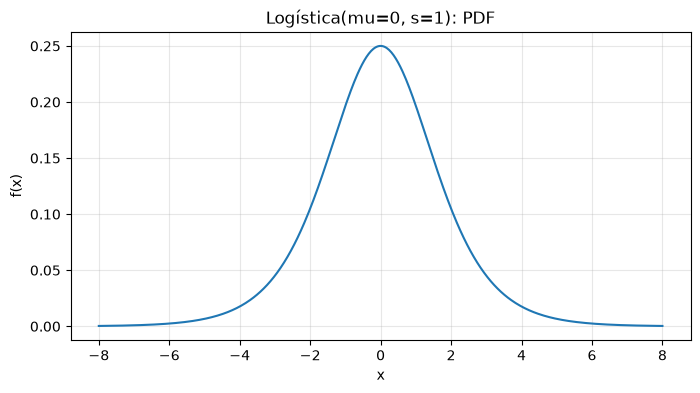

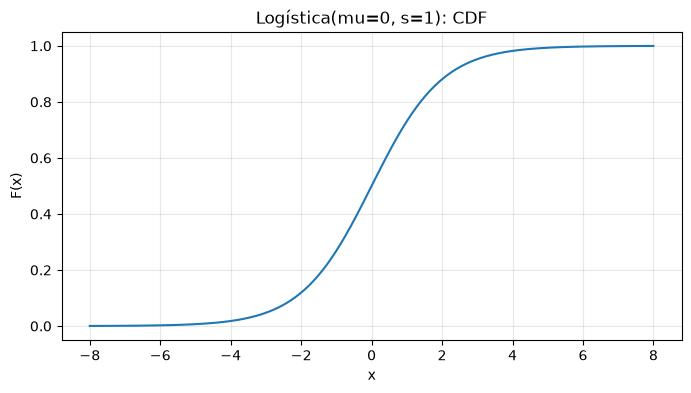


Triangular(a=0, moda=3, b=10)
E[X] = 4.333333333333334
Var(X) = 4.388888888888889


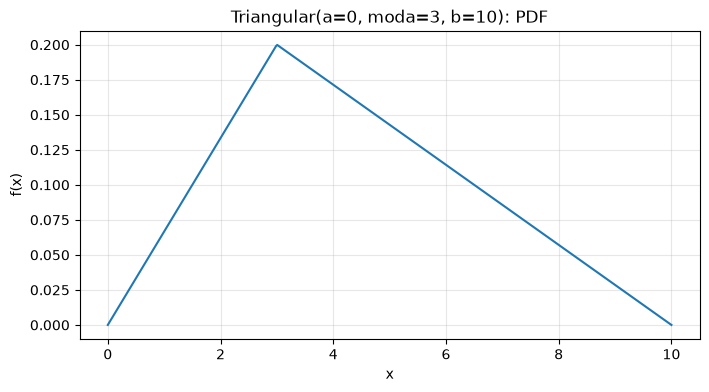

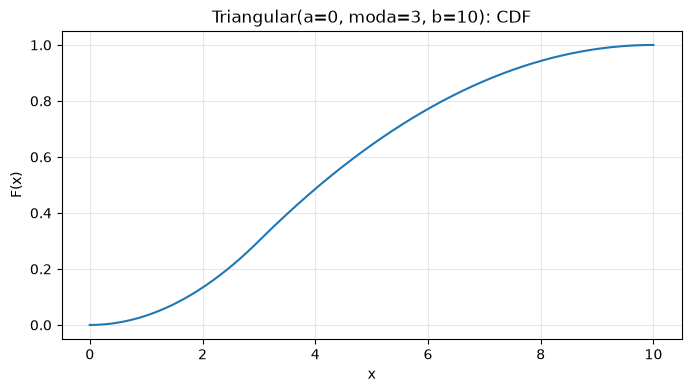

In [15]:
def graficar_continua(nombre, dist, x):
    pdf = dist.pdf(x)
    cdf = dist.cdf(x)

    plt.figure(figsize=(8, 4))
    plt.plot(x, pdf)
    plt.title(f"{nombre}: PDF")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(x, cdf)
    plt.title(f"{nombre}: CDF")
    plt.xlabel("x")
    plt.ylabel("F(x)")
    plt.grid(alpha=0.3)
    plt.show()

# Ejecuta esta celda para graficar todas las distribuciones continuas.
for d in continuas:
    print("\n" + d["nombre"])
    print("E[X] =", d["dist"].mean())
    print("Var(X) =", d["dist"].var())
    graficar_continua(d["nombre"], d["dist"], d["x"])

# 10. Función generadora de momentos

La **función generadora de momentos**, abreviada como FGM o MGF, se define como:

$$
M_X(t)=E[e^{tX}]
$$

Si existe alrededor de $t=0$, permite obtener momentos derivando:

$$
E[X]=M_X'(0)
$$

$$
E[X^2]=M_X''(0)
$$

y por tanto:

$$
Var(X)=M_X''(0)-[M_X'(0)]^2
$$

## Tabla de FGM

| Distribución | FGM |
|---|---|
| Bernoulli $(p)$ | $M_X(t)=1-p+pe^t$ |
| Binomial $(n,p)$ | $M_X(t)=(1-p+pe^t)^n$ |
| Poisson $(\lambda)$ | $M_X(t)=e^{\lambda(e^t-1)}$ |
| Geométrica $(p) $, soporte $1,2,\dots$ | $M_X(t)=\frac{pe^t}{1-(1-p)e^t}$ |
| Normal $(\mu,\sigma^2)$ | $M_X(t)=e^{\mu t+\frac{\sigma^2t^2}{2}}$ |
| Exponencial $(\lambda)$ | $M_X(t)=\frac{\lambda}{\lambda-t}$ |
| Gamma $(\alpha,\theta)$ | $M_X(t)=(1-\theta t)^{-\alpha}$ |
| Uniforme continua $U(a,b)$ | $M_X(t)=\frac{e^{tb}-e^{ta}}{t(b-a)}$ |

In [21]:
# Ejemplo simbólico: FGM de Poisson
t, lam = sp.symbols("t lambda", positive=True)

M = sp.exp(lam * (sp.exp(t) - 1))

E_X = sp.diff(M, t).subs(t, 0)
E_X2 = sp.diff(M, t, 2).subs(t, 0)
Var_X = sp.simplify(E_X2 - E_X**2)

print("FGM de Poisson:")
display(M)

print("E[X]:")
display(E_X)

print("E[X^2]:")
display(E_X2)

print("Var(X):")
display(Var_X)

FGM de Poisson:


exp(lambda*(exp(t) - 1))

E[X]:


lambda

E[X^2]:


lambda*(lambda + 1)

Var(X):


lambda

In [22]:
# Ejemplo simbólico: FGM de Normal
t = sp.symbols("t", real=True)
mu = sp.symbols("mu", real=True)
sigma = sp.symbols("sigma", positive=True)

M = sp.exp(mu*t + (sigma**2 * t**2)/2)

E_X = sp.diff(M, t).subs(t, 0)
E_X2 = sp.diff(M, t, 2).subs(t, 0)
Var_X = sp.simplify(E_X2 - E_X**2)

print("FGM de Normal:")
display(M)

print("E[X]:")
display(E_X)

print("E[X^2]:")
display(E_X2)

print("Var(X):")
display(Var_X)

FGM de Normal:


exp(mu*t + sigma**2*t**2/2)

E[X]:


mu

E[X^2]:


mu**2 + sigma**2

Var(X):


sigma**2

# 11. Función característica

La **función característica** se define como:

$$
\varphi_X(t)=E[e^{itX}]
$$

donde:

$$
i=\sqrt{-1}
$$

La FGM no siempre existe, pero la función característica siempre existe porque:

$$
|e^{itX}|=1
$$

Cuando la FGM existe:

$$
\varphi_X(t)=M_X(it)
$$

## Tabla de funciones características

| Distribución | Función característica |
|---|---|
| Bernoulli $(p)$ | $\varphi_X(t)=1-p+pe^{it}$ |
| Binomial $(n,p)$ | $\varphi_X(t)=(1-p+pe^{it})^n$ |
| Poisson $(\lambda)$ | $\varphi_X(t)=e^{\lambda(e^{it}-1)}$ |
| Normal $(\mu,\sigma^2)$ | $\varphi_X(t)=e^{i\mu t-\frac{1}{2}\sigma^2t^2}$ |
| Exponencial $(\lambda)$ | $\varphi_X(t)=\frac{\lambda}{\lambda-it}$ |
| Gamma $(\alpha,\theta)$ | $\varphi_X(t)=(1-i\theta t)^{-\alpha}$ |
| Cauchy $(x_0,\gamma)$ | $\varphi_X(t)=e^{ix_0t-\gamma \|t\|}$ |

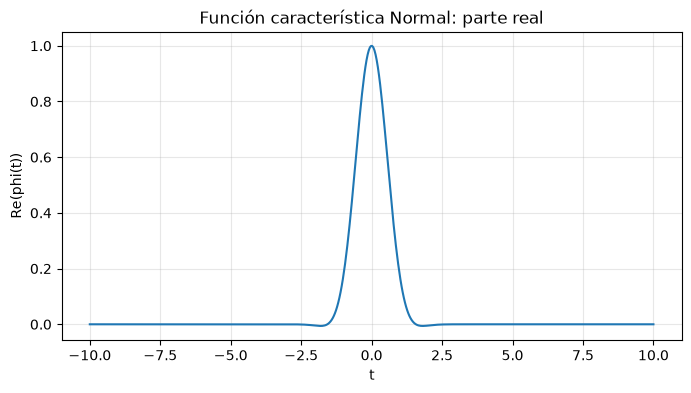

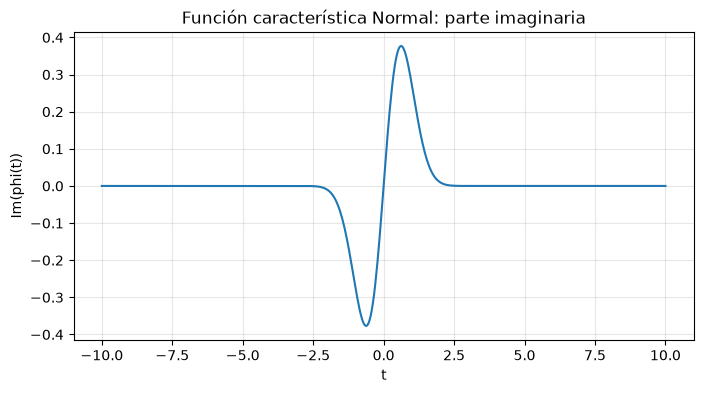

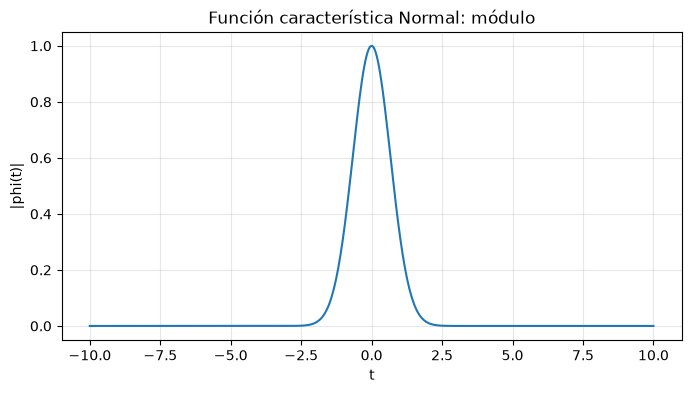

In [23]:
# Función característica de una normal
mu = 1
sigma = 1.5

t_vals = np.linspace(-10, 10, 500)
phi = np.exp(1j * mu * t_vals - 0.5 * sigma**2 * t_vals**2)

plt.figure(figsize=(8, 4))
plt.plot(t_vals, np.real(phi))
plt.title("Función característica Normal: parte real")
plt.xlabel("t")
plt.ylabel("Re(phi(t))")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t_vals, np.imag(phi))
plt.title("Función característica Normal: parte imaginaria")
plt.xlabel("t")
plt.ylabel("Im(phi(t))")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t_vals, np.abs(phi))
plt.title("Función característica Normal: módulo")
plt.xlabel("t")
plt.ylabel("|phi(t)|")
plt.grid(alpha=0.3)
plt.show()